In [2]:
import numpy as np
import matplotlib.pyplot as plt

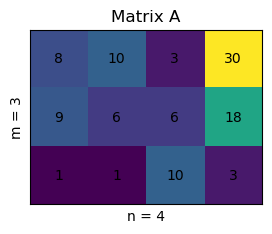

In [12]:
# i will take matrix mA from the exercise
mA = np.array([[8, 10, 3, 30], [9, 6, 6, 18], [1, 1, 10, 3]], dtype = np.float64)

fig, ax = plt.subplots(figsize=(3, 3))
ax.matshow(mA)

for (i, j), val in np.ndenumerate(mA):
    ax.text(j, i, f"{val:.0f}", ha='center', va='center')
ax.set_title('Matrix A')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel(f"n = {mA.shape[1]}")
ax.set_ylabel(f"m = {mA.shape[0]}")
plt.show()

In [48]:
# SVD decomposition
mU, vS, mVT = np.linalg.svd(mA)

# building of SIGMA matrix
mS = np.zeros(mA.shape)
np.fill_diagonal(mS, vS)


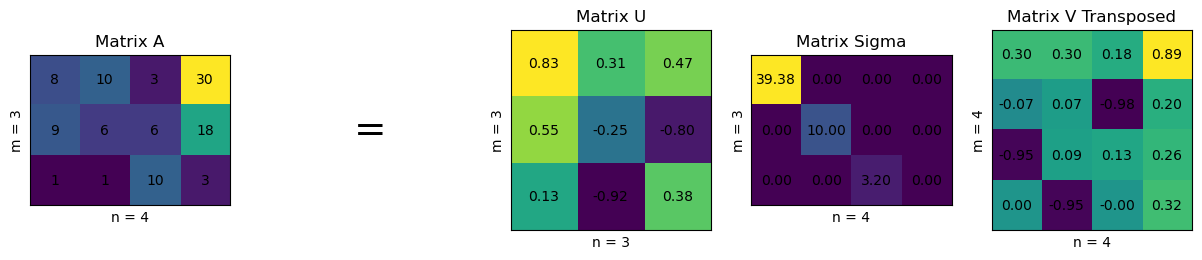

In [50]:
# here i want to visulize the Decomposition
fig, ax = plt.subplots(1, 5, figsize = (15, 3))

ax[0].matshow(mA)
for (i, j), val in np.ndenumerate(mA):
    ax[0].text(j, i, f"{val:.0f}", ha='center', va='center')
ax[0].set_title('Matrix A')
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_xlabel(f"n = {mA.shape[1]}")
ax[0].set_ylabel(f"m = {mA.shape[0]}")

ax[1].axis("off")
ax[1].text(0.5,0.5,"=",ha="center",va="center",fontsize=28)

ax[2].matshow(mU)
for (i, j), val in np.ndenumerate(mU):
    ax[2].text(j, i, f"{val:.2f}", ha='center', va='center')
ax[2].set_title('Matrix U')
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_xlabel(f"n = {mU.shape[1]}")
ax[2].set_ylabel(f"m = {mU.shape[0]}")

ax[3].matshow(mS)
for (i, j), val in np.ndenumerate(mS):
    ax[3].text(j, i, f"{val:.2f}", ha='center', va='center')
ax[3].set_title('Matrix Sigma')
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_xlabel(f"n = {mS.shape[1]}")
ax[3].set_ylabel(f"m = {mS.shape[0]}")

ax[4].matshow(mVT)
for (i, j), val in np.ndenumerate(mVT):
    ax[4].text(j, i, f"{val:.2f}", ha='center', va='center')
ax[4].set_title('Matrix V Transposed')
ax[4].set_xticks([])
ax[4].set_yticks([])
ax[4].set_xlabel(f"n = {mVT.shape[1]}")
ax[4].set_ylabel(f"m = {mVT.shape[0]}")
    
plt.show()


In [47]:
# the rank of matrix A is number of sgma values bigger than zero
rank_A = sum(vS > 10**(-6))
print(f"The rank of marix A is {rank_A}")

The rank of marix A is 3


In [56]:
# Curious to check wether mU @ mS @ mVT = ? mA
assert np.allclose(mA, mU @ mS @ mVT), "SVD reconstruction failed"
print("Test passed A = U @ Sigma @ V.T")

# Curious to check wether mU @ mU.T = I
assert np.allclose(np.eye(mA.shape[0]), mU @ mU.T), "mu @ mU.T != I"
print("Test passed U @ U.T = I")

Test passed A = U @ Sigma @ V.T
Test passed U @ U.T = I


[[ 9.65315109  9.66420881  5.82936997 28.99262643]
 [ 6.38343834  6.3907506   3.85484734 19.17225179]
 [ 1.49726764  1.49898276  0.90417387  4.49694829]]
[[-0.22344596  0.20470988 -3.02376293  0.61412965]
 [ 0.18297115 -0.16762891  2.47604108 -0.50288672]
 [ 0.66051825 -0.60513338  8.93840526 -1.81540015]]
[[-1.42970513  0.13108131  0.19439296  0.39324392]
 [ 2.4335905  -0.22312169 -0.33088841 -0.66936506]
 [-1.15778588  0.10615062  0.15742087  0.31845186]]


[]

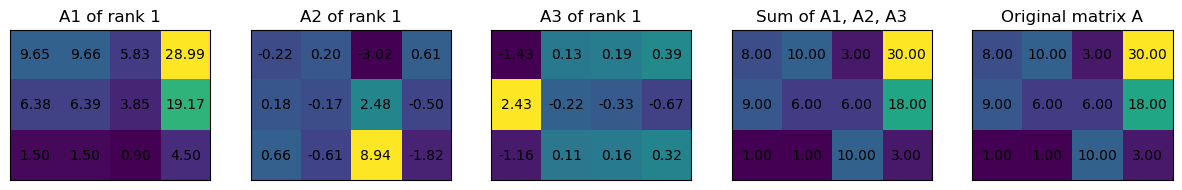

In [70]:
rank_one_terms = []
for i in range(rank_A):
    rank_one_terms.append(vS[i] * np.outer(mU[:, i], mVT[i, :]))
    print(rank_one_terms[i])

sum_Ais = rank_one_terms[0] + rank_one_terms[1] + rank_one_terms[2]
fig, ax = plt.subplots(1, 5, figsize = (15, 3))

ax[0].matshow(rank_one_terms[0])
for (i, j), val in np.ndenumerate(rank_one_terms[0]):
    ax[0].text(j, i, f"{val:.2f}", ha='center', va='center')
ax[0].set_title('A1 of rank 1')
ax[0].set_xticks([])
ax[0].set_yticks([])

ax[1].matshow(rank_one_terms[1])
for (i, j), val in np.ndenumerate(rank_one_terms[1]):
    ax[1].text(j, i, f"{val:.2f}", ha='center', va='center')
ax[1].set_title('A2 of rank 1')
ax[1].set_xticks([])
ax[1].set_yticks([])

ax[2].matshow(rank_one_terms[2])
for (i, j), val in np.ndenumerate(rank_one_terms[2]):
    ax[2].text(j, i, f"{val:.2f}", ha='center', va='center')
ax[2].set_title('A3 of rank 1')
ax[2].set_xticks([])
ax[2].set_yticks([])

ax[3].matshow(sum_Ais)
for (i, j), val in np.ndenumerate(sum_Ais):
    ax[3].text(j, i, f"{val:.2f}", ha='center', va='center')
ax[3].set_title('Sum of A1, A2, A3')
ax[3].set_xticks([])
ax[3].set_yticks([])

ax[4].matshow(mA)
for (i, j), val in np.ndenumerate(mA):
    ax[4].text(j, i, f"{val:.2f}", ha='center', va='center')
ax[4].set_title('Original matrix A')
ax[4].set_xticks([])
ax[4].set_yticks([])



In [69]:
mA

array([[ 8., 10.,  3., 30.],
       [ 9.,  6.,  6., 18.],
       [ 1.,  1., 10.,  3.]])